In [1]:
import json
import os
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy as scs
import xarray as xr

DIR_REPO = Path.cwd().parents[1]
if str(DIR_REPO) not in sys.path:
    sys.path.insert(0, str(DIR_REPO))
print(DIR_REPO)

np.set_printoptions(suppress=True)

/home/nnovikov/repo/A1-OUinp


In [2]:
fpath_in = (DIR_REPO / 'exp_results' / 'batch_rxbkg_unconn_state1_mech1' / 
            'net_inpsur_rsweep_newsec_var_seed_pre/ctx/wmat_tau_0.2.nc')
Q = xr.load_dataarray(fpath_in)
Q = Q.sel(pop_post=Q.pop_pre.values)
(Q * 1000).round(2)

<xarray.DataArray (pop_pre: 36, pop_post: 36)> Size: 10kB
array([[  65.51,   21.58,   13.88, ...,    9.7 ,   26.69,    7.38],
       [  90.  ,   83.93,   21.18, ...,    9.21,    0.  ,   10.35],
       [  19.12,    0.  ,   37.5 , ...,   13.64,   48.05, 4782.37],
       ...,
       [   0.  ,    2.62,  -29.11, ...,   30.31,   42.68,   -0.  ],
       [   2.32,    3.68,   -0.  , ...,   -7.84,     nan,    0.  ],
       [   0.  ,    0.  ,    0.  , ...,   15.27,   -0.  ,   -0.  ]],
      shape=(36, 36))
Coordinates:
  * pop_pre   (pop_pre) object 288B 'CT5A' 'CT5B' 'CT6' ... 'VIP5B' 'VIP6'
  * pop_post  (pop_post) object 288B 'CT5A' 'CT5B' 'CT6' ... 'VIP5B' 'VIP6'

In [3]:
PYR_POPS = ['IT2', 'IT3', 'ITP4', 'ITS4', 'IT5A', 'IT5B', 'IT6',
            'CT5A', 'CT5B', 'CT6', 'PT5B']
PV_POPS = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']
SOM_POPS = ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6']
VIP_POPS = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']
NGF_POPS = ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6']

L2_POPS = ['IT2', 'PV2', 'SOM2', 'VIP2', 'NGF2']
L3_POPS = ['IT3', 'PV3', 'SOM3', 'VIP3', 'NGF3']
L4_POPS = ['ITP4', 'ITS4', 'PV4', 'SOM4', 'VIP4', 'NGF4']
CTX_POPS = PYR_POPS + PV_POPS + SOM_POPS + VIP_POPS + NGF_POPS

In [4]:
def _to_list(x):
    if x is None:
        return []
    if np.isscalar(x):
        return [x]
    return list(x)


def plot_mat(ax, da, title=None, sep_x=None, sep_y=None, transpose=True, yinv=True, 
             show_xlabel=True, show_ylabel=True, show_xticklabels=True, show_yticklabels=True):
    if transpose:
        da = da.transpose('pop_post', 'pop_pre')
    else:
        da = da.transpose('pop_pre', 'pop_post')
    vmax = float(np.nanmax(np.abs(da.values)))
    im = ax.imshow(da.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax)
    if yinv:
        ax.invert_yaxis()

    pops_post = list(da.pop_post.values)
    pops_pre = list(da.pop_pre.values)

    if transpose:
        pops_x = pops_pre
        pops_y = pops_post
        xlabel_text = 'Pre'
        ylabel_text = 'Post'
    else:
        pops_x = pops_post
        pops_y = pops_pre
        xlabel_text = 'Post'
        ylabel_text = 'Pre'

    ax.set_xticks(range(len(pops_x)))
    if show_xticklabels:
        ax.set_xticklabels(pops_x, rotation=45, ha='right')
    else:
        ax.set_xticklabels([])
        
    ax.set_yticks(range(len(pops_y)))
    if show_yticklabels:
        ax.set_yticklabels(pops_y)
    else:
        ax.set_yticklabels([])

    if show_xlabel:
        ax.set_xlabel(xlabel_text)
    if show_ylabel:
        ax.set_ylabel(ylabel_text)

    if title is not None:
        ax.set_title(title)

    for sep_x_ in _to_list(sep_x):
        ax.axvline(x=sep_x_ - 0.5, color='k', lw=2)
    for sep_y_ in _to_list(sep_y):
        ax.axhline(y=sep_y_ - 0.5, color='k', lw=2)

def pow(x, k):
    return np.sign(x) * (np.abs(x) ** k)

In [5]:
pops = L2_POPS + L3_POPS
(Q.sel(pop_pre=pops, pop_post=pops) * 1000).round(2).T

<xarray.DataArray (pop_post: 10, pop_pre: 10)> Size: 800B
array([[   39.16,    -0.77,      nan,     0.  ,    -0.64,   650.69,
             nan,   -14.6 ,    -0.  ,  -163.11],
       [ 6574.07,   -18.67,    -0.  ,    -0.  ,    -0.  ,      nan,
         -581.6 , -1461.15,    -0.  ,   937.13],
       [ 1441.72,     0.  ,    -3.1 ,    -0.52,     0.  , 16734.39,
          -20.77,   -89.49,  -174.65,  -279.77],
       [ 1039.72,   -17.04,    -4.81,    -0.  ,      nan, 10454.87,
         -587.52, -1577.44,    -0.  ,     7.24],
       [  108.01,      nan,    -2.78,    -0.  ,    -0.  ,  1323.44,
          -79.85,  -631.17,   -14.13,    -3.  ],
       [   40.38,    -3.93,    -4.18,    -0.  ,    -0.98,   624.35,
          -71.99,   -51.08,    -3.8 ,  -119.54],
       [ 7316.03,   -31.18,    -9.68,    -0.  ,    -1.35,    -0.  ,
         -532.23, -1424.16,    -0.  ,     0.  ],
       [ 1927.58,    -0.27,     0.  ,      nan,    -0.04, 16711.54,
           -1.94,    -8.44,  -106.49,  -155.86],
       [  927.78,   -22.1 ,   -40.79,    -0.  ,    -0.  , 14682.95,
         -522.17,    -0.  ,    -0.  ,    -0.  ],
       [  137.79,    -0.77,   -15.16,    -0.  ,     0.  ,   792.66,
          -84.46,  -613.9 ,    -0.  ,    -0.01]])
Coordinates:
  * pop_pre   (pop_pre) object 80B 'IT2' 'PV2' 'SOM2' ... 'SOM3' 'VIP3' 'NGF3'
  * pop_post  (pop_post) object 80B 'IT2' 'PV2' 'SOM2' ... 'SOM3' 'VIP3' 'NGF3'

In [15]:
fpath_conn = DIR_REPO / 'conn' / 'conn.nc'
C = xr.load_dataset(fpath_conn)

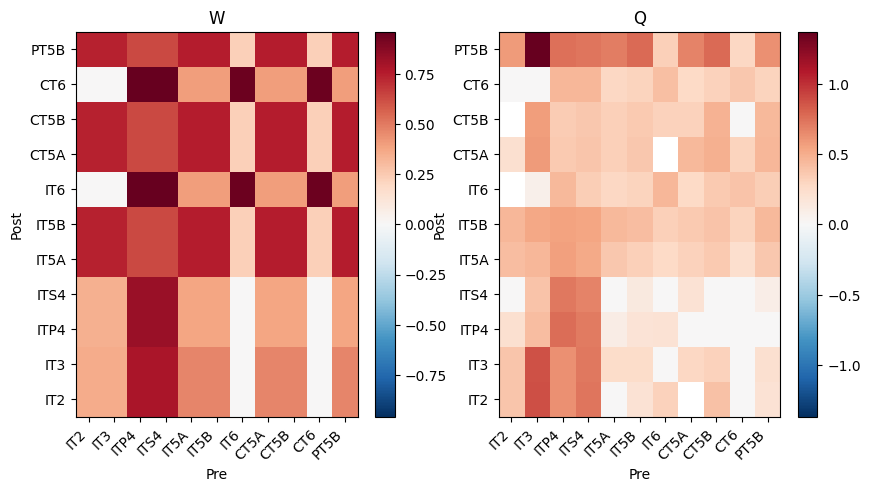

In [17]:
#pops = sorted(L4_POPS + L2_POPS + L3_POPS)
pops = PYR_POPS

Qvis = Q.sel(pop_pre=pops, pop_post=pops)
Qvis = pow(Qvis, 0.3)

# Keep only populations that are in W
Wvis = C.wmat.sel(pop_pre=pops, pop_post=pops)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_mat(axes[0], Wvis, 'W')
plot_mat(axes[1], Qvis, 'Q')

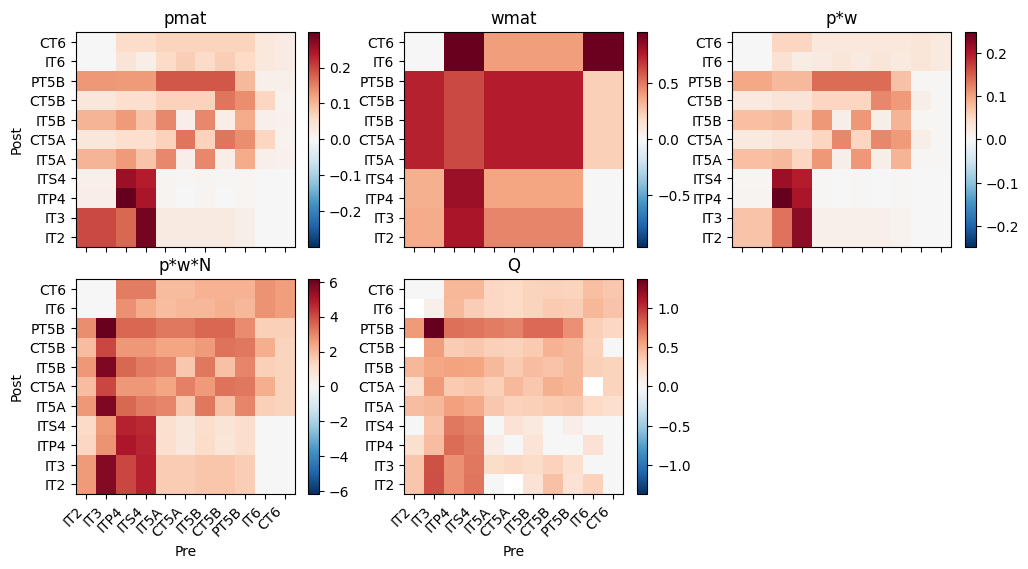

In [32]:
#pops = L2_POPS + L3_POPS
pops = ['IT2', 'IT3', 'ITP4', 'ITS4', 'IT5A', 'CT5A', 'IT5B', 'CT5B', 'PT5B', 'IT6', 'CT6']
pops_inh = PV_POPS + SOM_POPS + VIP_POPS + NGF_POPS

sign = xr.DataArray(
    np.where([p in pops_inh for p in C.pop_pre.values], -1.0, 1.0),
    dims='pop_pre',
    coords={'pop_pre': C.pop_pre.values},
)

pmat = C['pmat'].sel(pop_pre=pops, pop_post=pops)
wmat = (C['wmat'] * sign).sel(pop_pre=pops, pop_post=pops)
N = C['N'].sel(pop_pre=pops)
pw = pmat * wmat
pw_N = pow(pw * N, 0.3)
Qvis = pow(Q.sel(pop_pre=pops, pop_post=pops), 0.3)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
data_list = [pmat, wmat, pw, pw_N, Qvis]
titles = ['pmat', 'wmat', 'p*w', 'p*w*N', 'Q']

nrows, ncols = 2, 3
for idx, (ax, da, title) in enumerate(zip(axes.ravel(), data_list, titles)):
    row = idx // ncols
    col = idx % ncols
    plot_mat(
        ax,
        da,
        title,
        show_xlabel=(row == nrows - 1),
        show_ylabel=(col == 0),
        show_xticklabels=(row == nrows - 1),
        show_yticklabels=1  #(col == 0),
    )

axes[1, 2].axis('off')
fig.subplots_adjust(wspace=0.2, hspace=0.15)
plt.show()